In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import adspfilter
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#0e1117",
    "axes.edgecolor": "#e6edf3",
    "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3",
    "xtick.color": "#e6edf3",
    "ytick.color": "#e6edf3",
    "grid.color": "#2f3542",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#e6edf3",
    "font.size": 12,
})
COLOR_MAP = {
    "LMS": "#58a6ff",        # bright blue
    "NLMS": "#2dd4bf",       # cyan
    "APA (P=1)": "#f472b6",  # magenta
    "APA (P=2)": "#facc15",  # yellow
    "SignError": "#a3e635",  # lime
    "SignData": "#fb7185",   # red-pink
    "SignSign": "#c084fc",   # purple
    "DualSign": "#e879f9",
    "Pow2Err": "#fb923c",
}

In [2]:
train = False
M = 16
x = np.random.randn(4096)
true_w = np.random.randn(M)

fdaf = adspfilter.OverLapSaveFDAF(mu=0.1, filter_order=M-1)
fdaf.w = true_w.copy()
y_fdaf, _, _ = fdaf(x, np.zeros_like(x), train=False)

y_true = np.convolve(x, true_w)[:len(x)]

print(np.max(np.abs(y_fdaf - y_true)))

9.00763421185502e-07


2.1236019013764662e-06


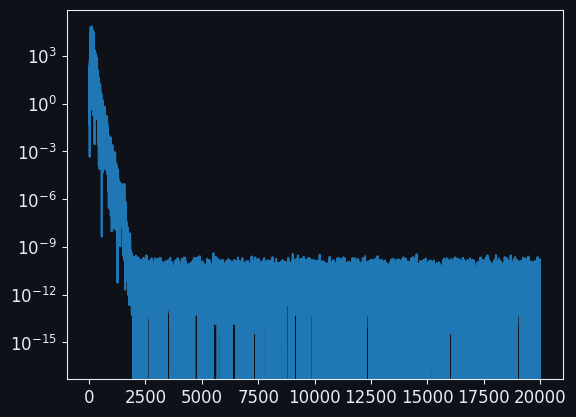

In [6]:
# Classic identification test.
M = 32
true_w = np.random.randn(M)
x = np.random.randn(20000)
d = np.convolve(x, true_w)[:len(x)]

fdaf = adspfilter.OverLapSaveFDAF(mu=0.5, filter_order=M-1)
y_hist, e_hist, w_hist = fdaf(x, d)
print(np.linalg.norm(fdaf.w - true_w))
plt.semilogy(np.abs(e_hist)**2)